Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       open      high       low     close        volume merge_date
0  93347.59  94960.91  92743.63  94383.59   6871.738482 2025-01-01
1  94383.59  97776.99  94177.00  96903.19  10912.473840 2025-01-02
2  96905.48  98969.92  96016.63  98136.51   9021.885382 2025-01-03
3  98139.85  98761.02  97516.65  98209.85   2742.089606 2025-01-04
4  98209.85  98814.00  97250.00  98345.33   2377.921759 2025-01-05
X shape: (100, 150, 1)
Y shape: (100, 63, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 63, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 63, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 63, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,273 (774.50 KB)

 Trainable params: 198,273 (774.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
5/5 - 8s - 2s/step - loss: 0.2991 - mae: 0.4713 - val_loss: 0.1623 - val_mae: 0.3776
Epoch 2/60
5/5 - 1s - 181ms/step - loss: 0.0648 - mae: 0.2086 - val_loss: 0.0406 - val_mae: 0.1634
Epoch 3/60
5/5 - 1s - 160ms/step - loss: 0.0518 - mae: 0.1859 - val_loss: 0.0187 - val_mae: 0.0987
Epoch 4/60
5/5 - 1s - 264ms/step - loss: 0.0272 - mae: 0.1316 - val_loss: 0.0394 - val_mae: 0.1720
Epoch 5/60
5/5 - 2s - 338ms/step - loss: 0.0285 - mae: 0.1380 - val_loss: 0.0177 - val_mae: 0.1030
Epoch 6/60
5/5 - 2s - 429ms/step - loss: 0.0240 - mae: 0.1206 - val_loss: 0.0169 - val_mae: 0.0945
Epoch 7/60
5/5 - 1s - 160ms/step - loss: 0.0232 - mae: 0.1185 - val_loss: 0.0176 - val_mae: 0.1049
Epoch 8/60
5/5 - 1s - 184ms/step - loss: 0.0212 - mae: 0.1203 - val_loss: 0.0214 - val_mae: 0.1211
Epoch 9/60
5/5 - 1s - 257ms/step - loss: 0.0201 - mae: 0.1168 - val_loss: 0.0156 - val_mae: 0.0970
Epoch 10/60
5/5 - 1s - 221ms/step - loss: 0.0196 - mae: 0.1110 - val_loss: 0.0148 - val_mae: 0.0935
Epoch 11/60


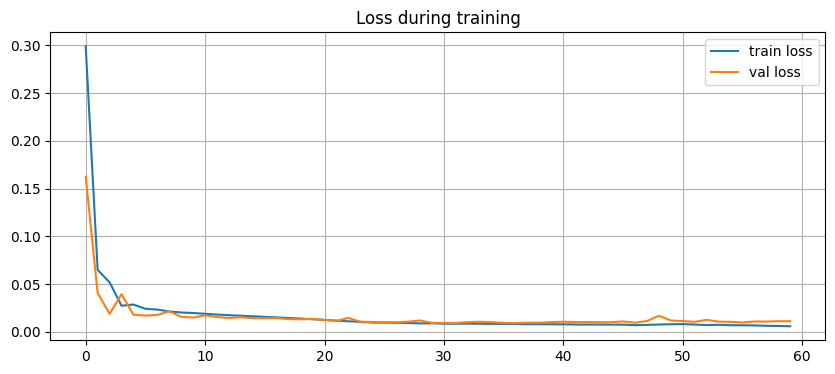

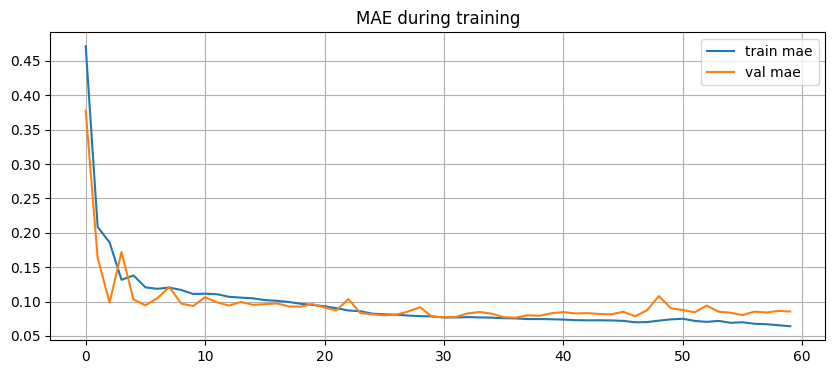

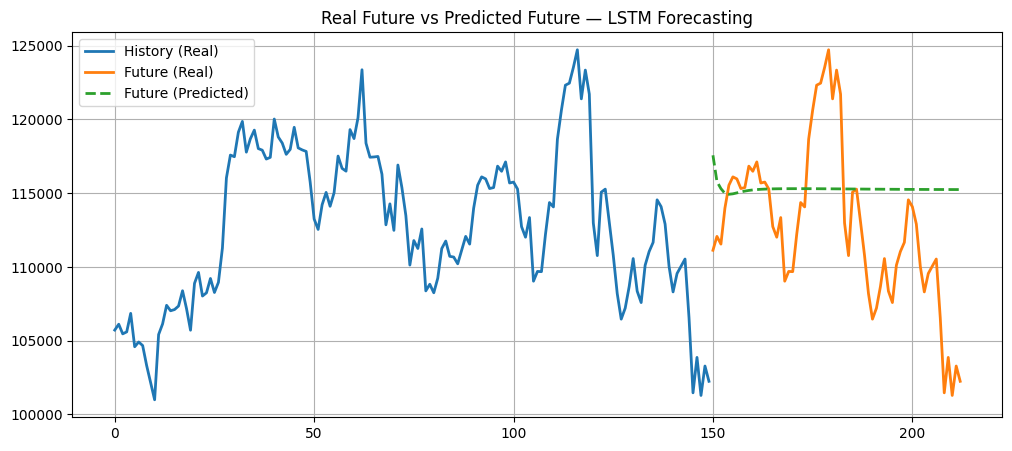

In [14]:
# -*- coding: utf-8 -*-
# ============================================
#   LSTM Time-Series Forecasting (Sliding Window)
#   HISTORY = 150, FORECAST = 63
#   Multiple training samples (≈ 99 samples)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

# ============================================================
# 1) خواندن دیتای واقعی از گوگل درایو
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/MyDrive/data/FINAL SELECTED DATA SET/Bitcoin.csv',
    sep=';',
    parse_dates=['merge_date'],
    dayfirst=True
)

print(df.head())

# ============================================================
# 2) انتخاب ستون close
# ============================================================

series = df['close'].values.astype(float)

if len(series) != 312:
    raise ValueError(f"طول سری باید ۳۱۲ باشد، اما دیتای شما: {len(series)}")

# ============================================================
# 3) Scale داده بین 0 و 1
# ============================================================
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series.reshape(-1,1)).flatten()

# ============================================================
# 4) تعریف پنجره‌ها
# ============================================================

HISTORY = 150
FORECAST = 63
TOTAL_WIN = HISTORY + FORECAST

X_list = []
Y_list = []

for start in range(len(series_scaled) - TOTAL_WIN + 1):
    end = start + HISTORY
    future_end = end + FORECAST

    x_window = series_scaled[start: end]
    y_window = series_scaled[end: future_end]

    X_list.append(x_window)
    Y_list.append(y_window)

X = np.array(X_list)
Y = np.array(Y_list)

# reshape برای LSTM
X = X.reshape(X.shape[0], HISTORY, 1)
Y = Y.reshape(Y.shape[0], FORECAST, 1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# ============================================================
# 5) ساخت مدل LSTM encoder-decoder
# ============================================================

model = Sequential([
    LSTM(128, activation='tanh', input_shape=(HISTORY, 1)),
    RepeatVector(FORECAST),
    LSTM(128, activation='tanh', return_sequences=True),
    TimeDistributed(Dense(1))
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ============================================================
# 6) آموزش مدل
# ============================================================

history = model.fit(
    X, Y,
    epochs=60,
    batch_size=16,
    validation_split=0.2,
    verbose=2
)

# ============================================================
# 7) رسم گراف‌های آموزش
# ============================================================

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title("Loss during training")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['mae'], label='train mae')
plt.plot(history.history['val_mae'], label='val mae')
plt.title("MAE during training")
plt.legend()
plt.grid()
plt.show()

# ============================================================
# 8) پیش‌بینی 63 گام آینده با استفاده از آخرین 150 مقدار سری
# ============================================================

# ============================================================
# رسم تاریخچه، آینده واقعی و آینده پیش‌بینی شده
# ============================================================

# history (آخرین 150 مقدار)
history_real = scaler.inverse_transform(last_history.reshape(-1,1)).flatten()

# future real از دیتای اصلی (63 مقدار آینده)
actual_future = series[-FORECAST:]   # آخرین 63 مقدار واقعی

# predicted future (از مدل)
pred_future = pred

plt.figure(figsize=(12,5))
plt.plot(range(HISTORY), history_real, label='History (Real)', linewidth=2)
plt.plot(range(HISTORY, HISTORY+FORECAST), actual_future, label='Future (Real)', linewidth=2)
plt.plot(range(HISTORY, HISTORY+FORECAST), pred_future, '--', label='Future (Predicted)', linewidth=2)

plt.title("Real Future vs Predicted Future — LSTM Forecasting")
plt.legend()
plt.grid()
plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


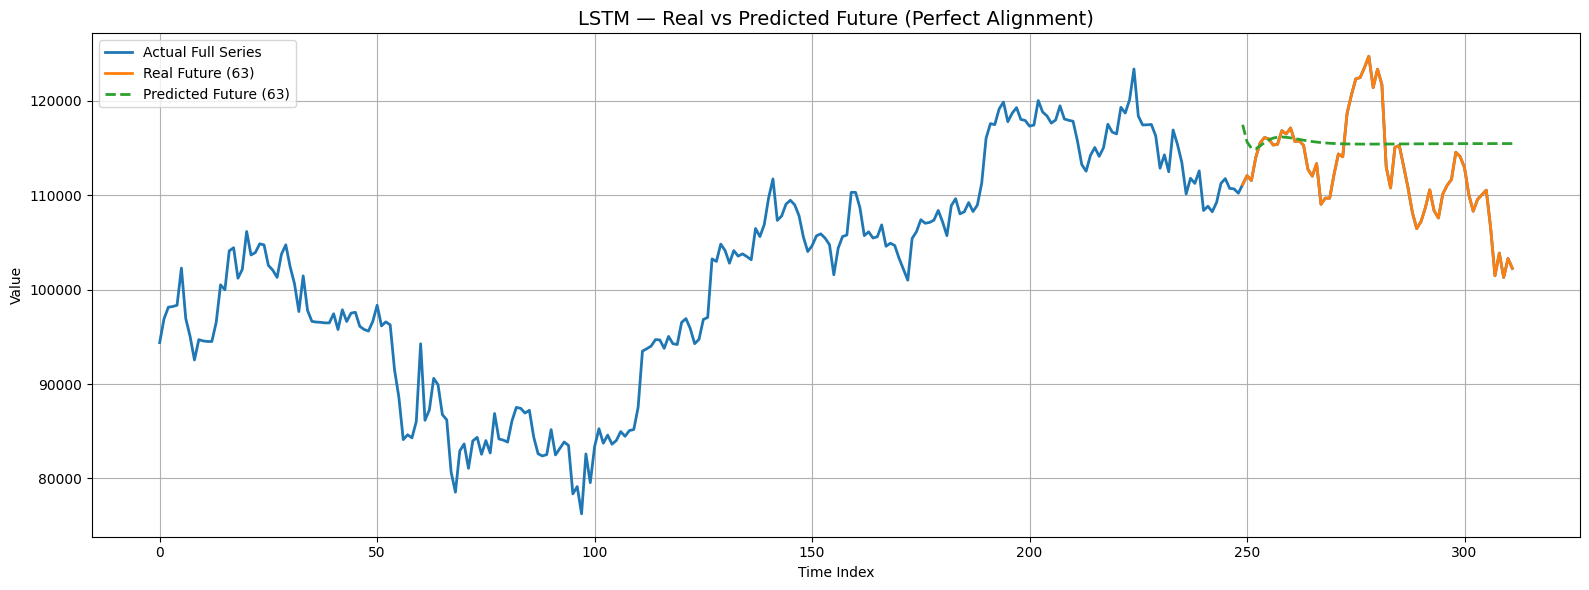

In [16]:
# ============================================================
# 9) پیش‌بینی بر اساس آخرین HISTORY مقدار
# ============================================================

last_history = series_scaled[-HISTORY:]
last_history = last_history.reshape(1, HISTORY, 1)

pred_scaled = model.predict(last_history)[0].flatten()
pred = scaler.inverse_transform(pred_scaled.reshape(-1,1)).flatten()

# ============================================================
# 10) رسم دقیق و تمیز — بدون فاصله و جابه‌جایی
# ============================================================

plt.figure(figsize=(16,6))

# 1) کل سری واقعی
plt.plot(full_series, label='Actual Full Series', linewidth=2)

# 2) آینده واقعی (63 مقدار آخر)
real_future_start = len(full_series) - FORECAST
real_future_end = len(full_series)

plt.plot(
    range(real_future_start, real_future_end),
    actual_future,
    label='Real Future (63)', linewidth=2
)

# 3) آینده پیش‌بینی شده دقیقاً بر روی همان محور
pred_start = real_future_start
pred_end = pred_start + FORECAST

plt.plot(
    range(pred_start, pred_end),
    pred,
    '--',
    label='Predicted Future (63)', linewidth=2
)

plt.title("LSTM — Real vs Predicted Future (Perfect Alignment)", fontsize=14)
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
